In [204]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import math


import warnings
warnings.filterwarnings('ignore')

# Basics of NumPy: Matrix operations

NumPy docs: https://numpy.org/doc/stable/reference/index.html

### 1. Define numpy arrays

In [205]:
A = np.array([[1,2,3],[4,5,6]])
print("A.shape:",A.shape)

B = np.array([[1.0,2.3],[3.5,5.7],[8.9,9.2]])
print("B.shape:",B.shape)

x = np.array([1.0,2.0,3.0])
print("x.shape:",x.shape)

y = np.array([[1.0,2.0,3.0]])
print("y.shape:",y.shape)

z = np.array([[1.0],[2.0],[3.0]])
print("z.shape:",z.shape)

A.shape: (2, 3)
B.shape: (3, 2)
x.shape: (3,)
y.shape: (1, 3)
z.shape: (3, 1)


### Exercise

* Create a 2D array of shape `(3,4)` where each row is `[1, 2, 3, 4]`. What is its shape?
* What will be the shape of `x[:, None] + y`? Why?

In [206]:
_2d_array = np.array([[1,2,3,4], [1,2,3,4], [1,2,3,4], [1,2,3,4]])
print("2D array shape:", _2d_array.shape)

new_array = x[:, None] + y
print("x[:, None] + y shape", new_array.shape)

2D array shape: (4, 4)
x[:, None] + y shape (3, 3)


### 2. Access to matrix

In [207]:
D = np.array([
        [1, 4, 5, 12], 
        [-5, 8, 9, 0],
        [-6, 7, 11, 19]
    ])
print("D.shape:",D.shape,"\n")

print("Access to elements: D[0,2] =",D[0,2],"\n")

print("Access to rows")
print("D[0]  =", D[0]) # First Row
print("D[2]  =", D[2]) # Third Row
print("D[-1] =", D[-1], "\n") # Last Row (3rd row in this case)

print("Access to columns")
print("D[:,0]  =", D[:,0]) # First Column
print("D[:,3]  =", D[:,3]) # Fourth Column
print("D[:,-1] =", D[:,-1]) # Last Column (4th column in this case)

D.shape: (3, 4) 

Access to elements: D[0,2] = 5 

Access to rows
D[0]  = [ 1  4  5 12]
D[2]  = [-6  7 11 19]
D[-1] = [-6  7 11 19] 

Access to columns
D[:,0]  = [ 1 -5 -6]
D[:,3]  = [12  0 19]
D[:,-1] = [12  0 19]


### 3. Slicing matrix

In [208]:
D = np.array([
    [1, 4, 5, 12, 14], 
    [-5, 8, 9, 0, 17],
    [-6, 7, 11, 19, 21]])
print("D.shape:",D.shape,"\n")

D.shape: (3, 5) 



In [209]:
print(D[:2, :4])  # two rows, four columns

[[ 1  4  5 12]
 [-5  8  9  0]]


In [210]:
print(D[:1,:])  # first row, all columns

[[ 1  4  5 12 14]]


In [211]:
print(D[:,2])  # all rows, third column

[ 5  9 11]


In [212]:
print(D[:,2:3])  # all rows, third column, but as a column; 

[[ 5]
 [ 9]
 [11]]


In [213]:
print(D[:, 2:])  # all rows, third to the fifth column

[[ 5 12 14]
 [ 9  0 17]
 [11 19 21]]


### Exercise

* Reverse the rows of D using slicing. (Hint: Look into `array[start_idx:stop_idx:step]`)
* What is the difference between `D[:, 2:3]` and `D[:, 2]`? Explain why they are different?

In [214]:
D = D[::-1,:]
print(D)

[[-6  7 11 19 21]
 [-5  8  9  0 17]
 [ 1  4  5 12 14]]


### 4. Matrix operations

In [215]:
print("A:\n",A)
print()
print("B:\n",B)
print()
print("x:\n",z)
print()
print("z:\n",z)

A:
 [[1 2 3]
 [4 5 6]]

B:
 [[1.  2.3]
 [3.5 5.7]
 [8.9 9.2]]

x:
 [[1.]
 [2.]
 [3.]]

z:
 [[1.]
 [2.]
 [3.]]


In [216]:
A_plus_A = A + A
print("A_plus_A:\n",A_plus_A,"\n")

AB = A @ B
print("AB:\n",AB,"\n")

BA = B @ A
print("BA:\n",BA,"\n")

A_at_x = A @ x
print("A_at_x:\n",A_at_x,"\n")

A_times_x = A * x
print("A_times_x\n", A_times_x,"\n")

Az = A @ x
print("Az:\n",Az,"\n")

A_T = A.T
print("A has shape",A.shape,", A transpose has shape ",A_T.shape)

A_plus_A:
 [[ 2  4  6]
 [ 8 10 12]] 

AB:
 [[34.7 41.3]
 [74.9 92.9]] 

BA:
 [[10.2 13.5 16.8]
 [26.3 35.5 44.7]
 [45.7 63.8 81.9]] 

A_at_x:
 [14. 32.] 

A_times_x
 [[ 1.  4.  9.]
 [ 4. 10. 18.]] 

Az:
 [14. 32.] 

A has shape (2, 3) , A transpose has shape  (3, 2)


### Matrix Multiplication

Recall that for any two matrices
$$A = \begin{bmatrix} 
    a_{11} & \dots  & a_{1M}\\
    \vdots & \ddots & \vdots\\
    a_{L1} & \dots  & a_{LM} 
    \end{bmatrix} \in\mathbb{R}^{L\times M}$$
and
$$B = \begin{bmatrix} 
    b_{11} & \dots  & b_{1N}\\
    \vdots & \ddots & \vdots\\
    b_{M1} & \dots  & b_{MN} 
    \end{bmatrix} \in\mathbb{R}^{M\times N} \,,$$
the matrix product $AB \in \mathbb{R}^{L\times N}$ is given by
$$(AB)_{i, k} = \sum_{j = 1}^{M} a_{i, j} b_{j, k} \,,$$
for $i = 1, \ldots, L$ and $k = 1, \ldots, N$.

### Exercise

* Implement a function `matmul_manual(A, B)` that mimics matrix multiplication by only using `for` loops.
* What is the difference between `A @ B` and `A * B`?

In [217]:
def matmul_manual(A, B):
    C = [[0 for _ in range(len(B[0]))] for _ in range(len(A))]
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                C[i][j] += A[i][k] * B[k][j]
                
    return np.array(C)

# Decrease the size, if matmul_manual is taking too long. Increase it, if
# it is not taking long enough.
A = np.random.randn(50, 30)
B = np.random.randn(30, 40)

print("Using built-in matrix multiplcation of numpy...")
AB_numpy = A @ B
print("Done!!!")
print("Using manual matrix multiplcation...")
AB_manual = matmul_manual(A, B)
print("Done!!!")

assert np.allclose(AB_numpy, AB_manual)



Using built-in matrix multiplcation of numpy...
Done!!!
Using manual matrix multiplcation...
Done!!!


# Plotting in Python using Matplotlib

### 1. Line plot

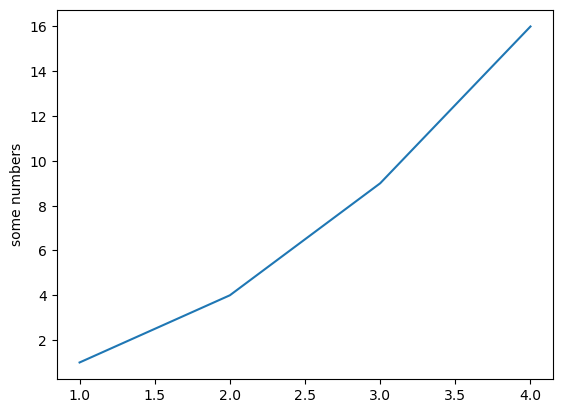

In [218]:
z = [1, 2, 3, 4]
y = [1, 4, 9, 16]
plt.plot(z, y)
plt.ylabel('some numbers')
plt.show()

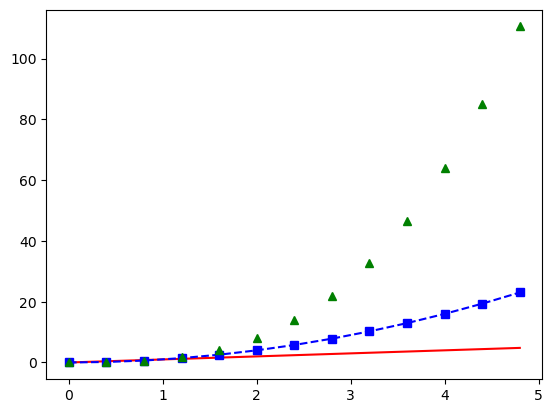

In [219]:
z = np.arange(0., 5., 0.4) # [0. 0.4 ... 4.4 4.8]

# red line, blue squares connected with dashes and green triangles
plt.plot(z, z, 'r-')
plt.plot(z, z**2, 'bs--')
plt.plot(z, z**3, 'g^')
plt.show()

### 2. Plotting with categorical variables

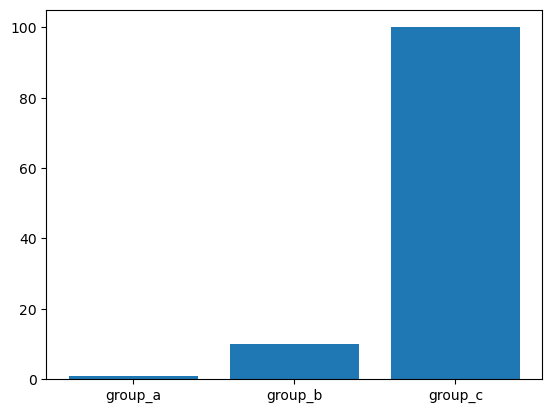

In [220]:
names = ['group_a', 'group_b', 'group_c']
values = [1, 10, 100]

plt.bar(names, values)
plt.show()

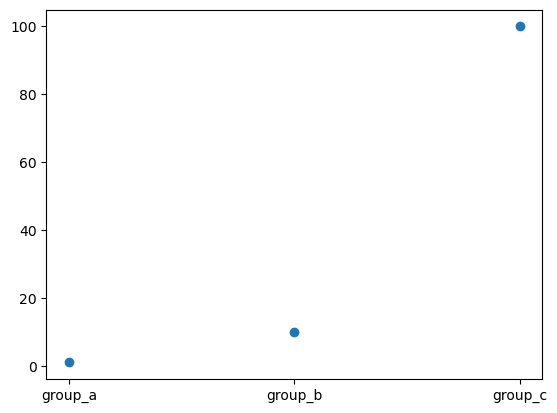

In [221]:
plt.scatter(names, values)
plt.show()

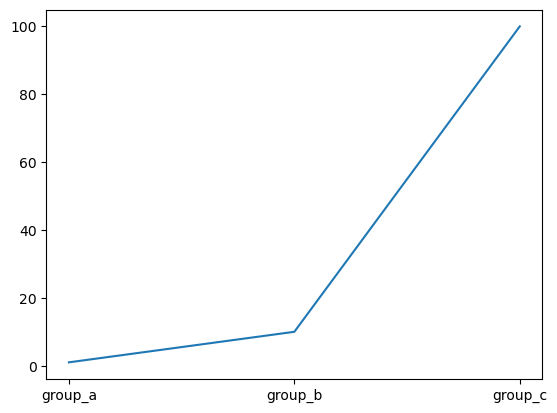

In [222]:
plt.plot(names, values)
plt.show()

### 3. Multiple axes

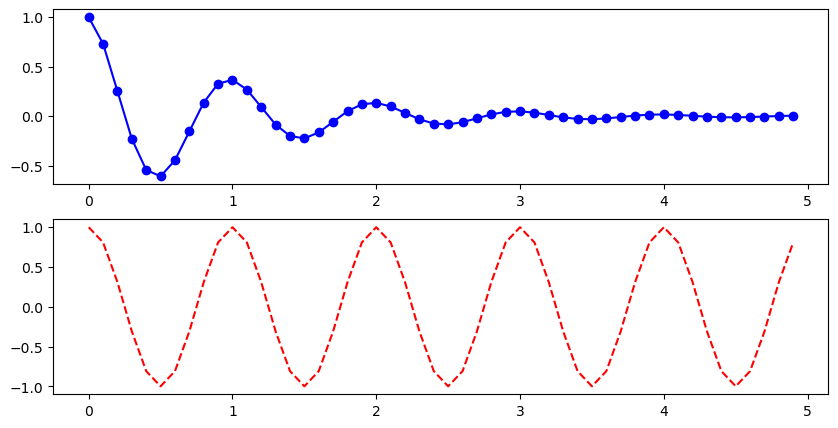

In [223]:
def f(t):
    return np.exp(-t) * np.cos(2*np.pi*t)

x1 = np.arange(0.0, 5.0, 0.1) # [0.0 0.1 ... 4.8 4.9]

fig,ax = plt.subplots(2,1,figsize = (10,5))
ax[0].plot(x1, f(x1), 'bo-')
ax[1].plot(x1, np.cos(2*np.pi*x1), 'r--') # r--
fig.show()

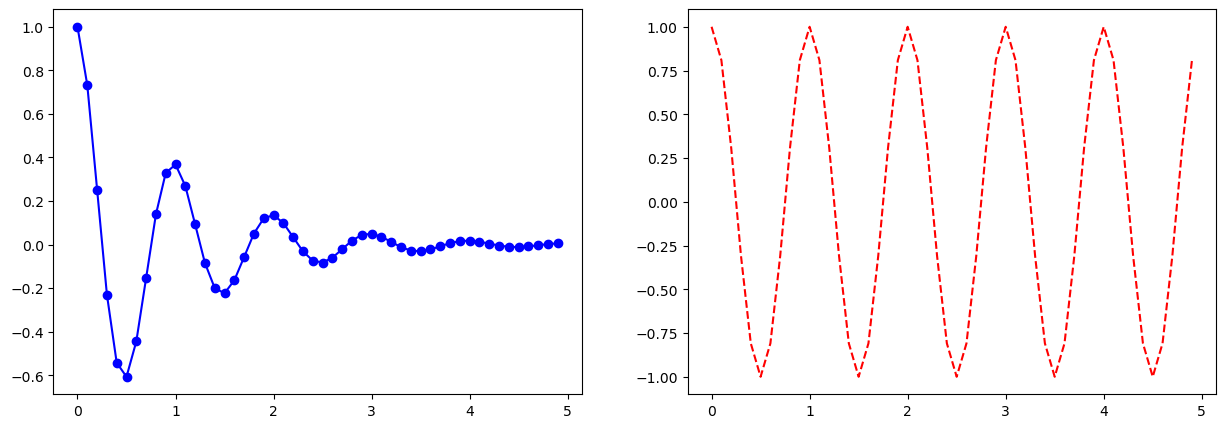

In [224]:
fig,ax = plt.subplots(1,2,figsize = (15,5))
ax[0].plot(x1, f(x1), 'bo-')
ax[1].plot(x1, np.cos(2*np.pi*x1), 'r--')
fig.show()

### 4. Plotting margin-based loss functions

In binary classification, the goal is to predict a label $y \in \{-1, +1\}$ for a given input $x \in \mathbb{R}^d$. The prediction is made using a function $f$, typically a linear function such as $f(x) = w^\top x + b$. The sign of $f(x)$ determines the predicted class label.

To measure how well $f(x)$ performs, we define a **loss function** $\ell(y, f(x))$, which quantifies the cost of predicting $f(x)$ when the true label is $y$.

Some commonly used loss functions in binary classification are:

* **0-1 Loss**

$$L(y, f(x)) = 
\begin{cases}
1 & \text{if } y f(x) < 0 \\
0 & \text{otherwise}
\end{cases}$$

* **Hinge Loss**

$$L(y, f(x)) = \max(0, 1 - y f(x))$$

* **Truncated Squared Loss**

$$L(y, f(x)) = \max(0, 1 - y f(x))^2$$

* **Exponential Loss**

$$L(y, f(x)) = \exp(-y f(x))$$

* **Logistic Loss**

$$L(y, f(x)) = \log(1 + \exp(-y f(x)))$$

### Exercise

* Provide the implementation of *0-1* loss, *hinge* loss, and *exponential* loss. You are given a 1-dimensional NumPy array `z`, where each element is defined as $z_i := y_i \cdot f(x_i)$. Your task is to return a NumPy array of the same shape as `z` containing the respective loss values $L (y_i, f(x_i))$ for each entry. Try to avoid the `for` loops or list comprehensions.

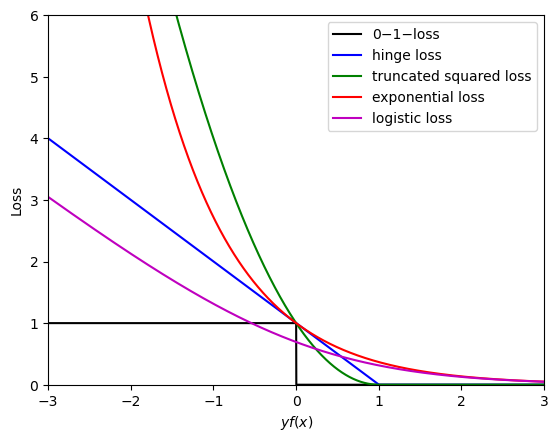

In [225]:
def zero_one_loss(z):
    return np.where(z > 0, 0, 1)

def hinge_loss(z):
    return np.maximum(0, 1 - z)

def truncated_squared_loss(z):
    return hinge_loss(z)**2

def exponential_loss(z):
    return np.exp(-z)

def logistic_loss(z):
    return np.log(1 + np.exp(-z))

z = np.arange(-3, 3, 0.001)

plt.plot(z, zero_one_loss(z), c='k', label='0−1−loss')
plt.plot(z, hinge_loss(z), c='b', label='hinge loss')
plt.plot(z, truncated_squared_loss(z), c='g', label='truncated squared loss')
plt.plot(z, exponential_loss(z), c='r', label='exponential loss')
plt.plot(z, logistic_loss(z), c = 'm', label='logistic loss')

plt.ylim([0,6])
plt.xlim([-3,3])
plt.xlabel('$yf(x)$')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 5. Plotting loss functions for linear regression

Similarly, in linear regression, the goal is to predict the output $y \in \mathbb{R}$ for a given input $x \in \mathbb{R}^d$. The prediction is made using a function $f$ defined as $f(x) = w^\top x + b$.

To measure how well $f(x)$ performs, we define a **loss function** $\ell(y, f(x))$, which quantifies the cost of predicting $f(x)$ when the true label is $y$.

Some commonly used loss functions in linear regression are

* **Squared Loss**

$$L(y, f(x)) = \frac{1}{2} (y - f(x))^2$$

* **$\ell_1$ - Loss**

$$L(y, f(x)) = \lvert y - f(x)\rvert$$

* **$\epsilon$-Insensitive Loss**

$$L(y, f(x)) = 
\begin{cases}
0 & \text{if } |y - f(x)| \leq \varepsilon \\
|y - f(x)| - \varepsilon & \text{otherwise}
\end{cases}$$

* **Huber's Robust Loss**

$$L(y, f(x)) = 
\begin{cases}
\frac{1}{2}(y - f(x))^2 & \text{if } |y - f(x)| \leq \epsilon \\
\epsilon (|y - f(x)| - \frac{\epsilon}{2}) & \text{otherwise}
\end{cases}$$

### Exercise

* Provide the implementation of *$\epsilon$-insensitive* loss, and *Huber's* loss. You are given a 1-dimensional NumPy array `z`, where each element is defined as $z_i := y_i - f(x_i)$. Your task is to return a NumPy array of the same shape as `z` containing the respective loss values $L (y_i, f(x_i))$ for each entry. Try to avoid the `for` loops or list comprehensions wherever possible.

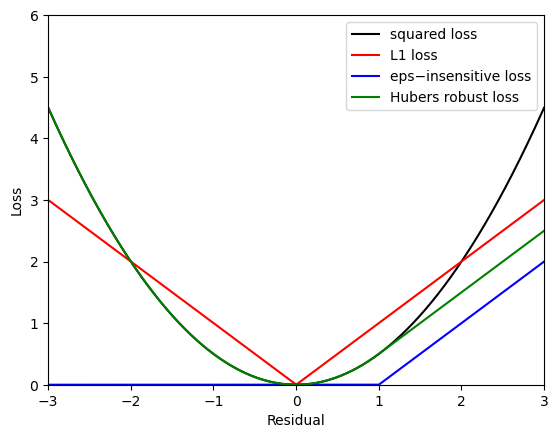

In [226]:
def squared_loss(z):
    return 0.5 * z**2

def l1_loss(z):
    return np.abs(z)

def epsilon_insensitive_loss(z, eps):
    return np.where(z < eps, 0, z-eps)

def huber_loss(z, eps):
    return np.where(z < eps, 0.5 * z**2, eps* (abs(z) - 0.5 * eps))

z = np.arange(-3, 3, 0.001)
eps = 1

plt.plot(z, squared_loss(z), c='k', label='squared loss') 
plt.plot(z, l1_loss(z), c='r', label='L1 loss')
plt.plot(z, epsilon_insensitive_loss(z, eps), c='b', label='eps−insensitive loss')
plt.plot(z, huber_loss(z, eps), c='g', label='Hubers robust loss')

plt.ylim([0,6])
plt.xlim([-3,3])
plt.xlabel('Residual')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Polynomial curve fitting

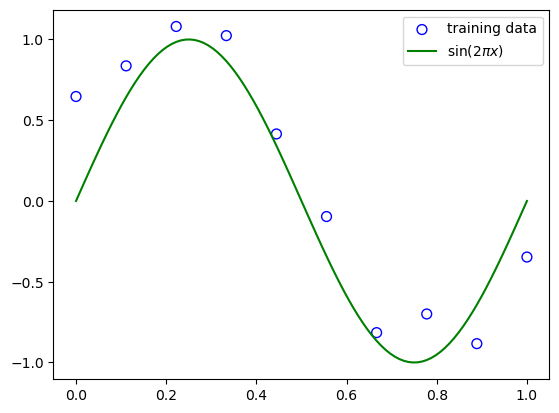

In [227]:
def func(x):
    return np.sin(2 * np.pi * x)

def create_data(func, sample_size, std):
    x = np.linspace(0, 1, sample_size)
    t = func(x) + np.random.normal(scale=std, size=x.shape)
    return x, t

x_train, y_train = create_data(func, sample_size=10, std=0.25)
x_test, y_test = create_data(func, sample_size=100, std=0.00)

plt.scatter(x_train, y_train, facecolor="none", edgecolor="b", s=50, label="training data")
plt.plot(x_test, y_test, c="g", label="$\sin(2\pi x)$")
plt.legend()
plt.show()

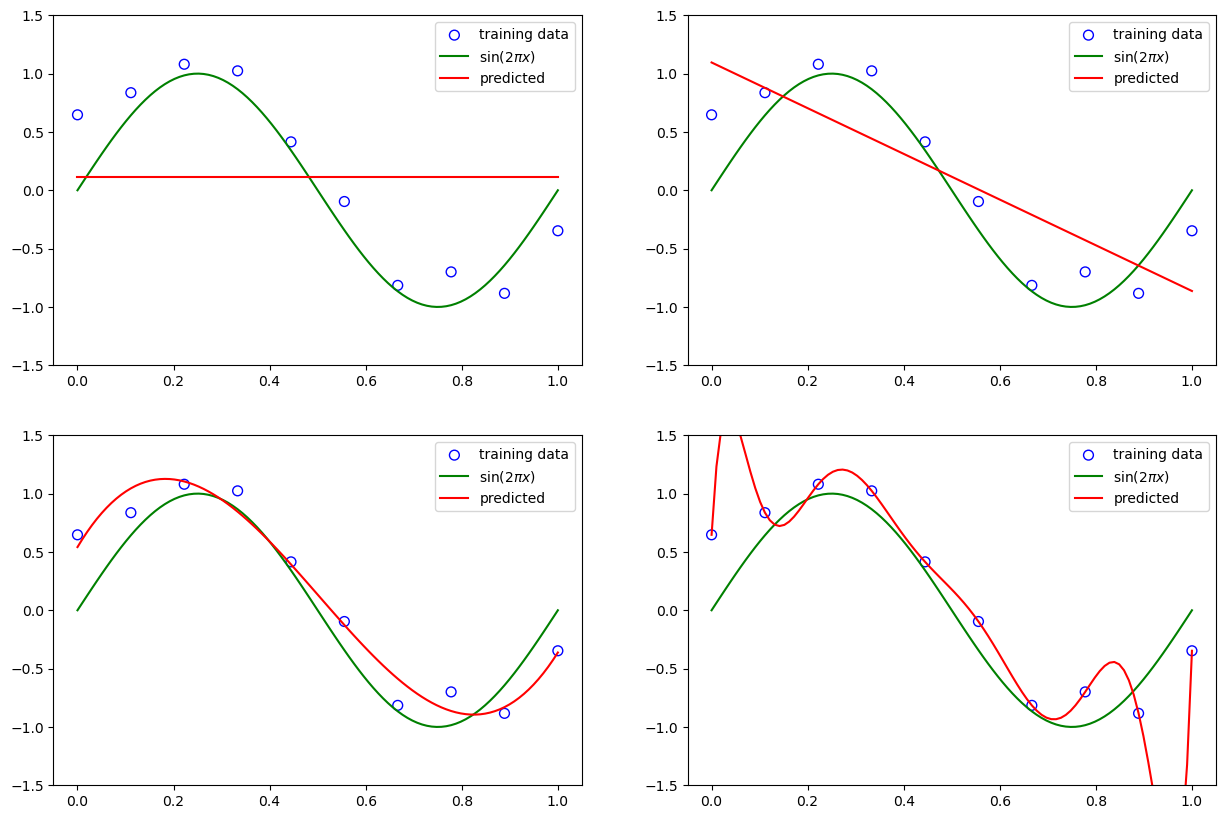

In [228]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(15,10))

for i, degree in enumerate([0, 1, 3, 9]):
    plt.subplot(2, 2, i + 1)
    
    feature = PolynomialFeatures(degree).fit(x_train[:,None])
    X_train = feature.transform(x_train[:,None])
    X_test = feature.transform(x_test[:,None])

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    plt.scatter(x_train, y_train, facecolor="none", edgecolor="b", s=50, label="training data")
    plt.plot(x_test, y_test, c="g", label="$\sin(2\pi x)$")
    plt.plot(x_test, y_pred, c="r", label="predicted")
    plt.ylim(-1.5, 1.5)
    plt.annotate("M={}".format(degree), xy=(-0.15, 1))
    plt.legend(loc=0)
    
plt.show()

## Root Mean Square Error (RMSE)

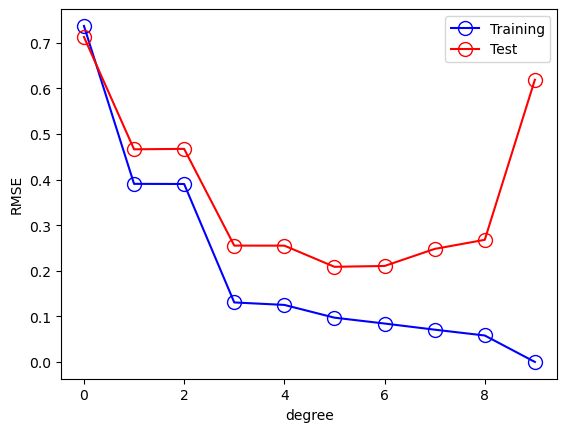

In [229]:
def rmse(a, b):
    return np.sqrt(np.mean(np.square(a - b)))

training_errors = []
test_errors = []

for i in range(10):
    feature = PolynomialFeatures(i).fit(x_train[:,None])
    X_train = feature.transform(x_train[:,None])
    X_test = feature.transform(x_test[:,None])

    model = LinearRegression()
    model.fit(X_train, y_train)
    y = model.predict(X_test)
    training_errors.append(rmse(model.predict(X_train), y_train))
    test_errors.append(rmse(model.predict(X_test), y_test ))

plt.plot(training_errors, 'o-', mfc="none", mec="b", ms=10, c="b", label="Training")
plt.plot(test_errors, 'o-', mfc="none", mec="r", ms=10, c="r", label="Test")
plt.legend()
plt.xlabel("degree")
plt.ylabel("RMSE")
plt.show()

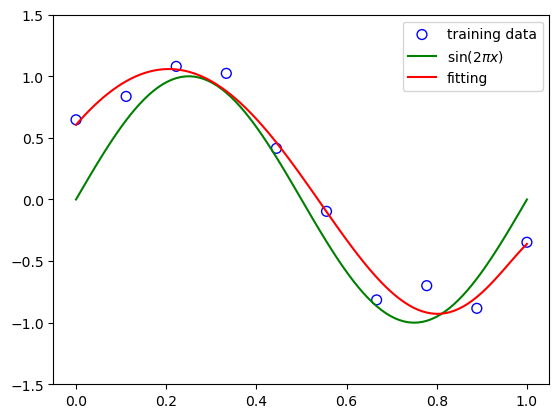

RMSE: 0.23


In [230]:
from sklearn.linear_model import Ridge as RidgeRegression

feature = PolynomialFeatures(9).fit(x_train[:,None])
X_train = feature.transform(x_train[:,None])
X_test = feature.transform(x_test[:,None])

model = RidgeRegression(alpha=1e-4)
model.fit(X_train, y_train)
y = model.predict(X_test)

plt.scatter(x_train, y_train, facecolor="none", edgecolor="b", s=50, label="training data")
plt.plot(x_test, y_test, c="g", label="$\sin(2\pi x)$")
plt.plot(x_test, y, c="r", label="fitting")
plt.ylim(-1.5, 1.5)
plt.legend()
plt.show()

print("RMSE:", round(rmse(y,y_test),2))

# Central Limit Theorem

## What does it say?
Given N iid random variables $X_1$ to $X_N$, and let their common distribution have finite expectation $\mu$ and finite variance $\sigma^2>0$.

We form a new random variable $Z_n$ by averaging: $Z_n = \frac{1}{n} \sum_{i=1}^{n} X_i$.

According to central limit theorem:
1. $Z_n$ has expectation $\mu$. $\rightarrow$ obvious, since $\mathbb{E}[\frac{1}{n} \sum_{i=1}^{n} X_i] = \frac{1}{n} \sum_{i=1}^{n} \mathbb{E}[X_i] = \frac{1}{n}*n*\mu=\mu$
2. $Z_n$ has variance $\sigma^2/n$.
    $\rightarrow$ obvious, since $Var(\frac{1}{n} \sum_{i=1}^{n} X_i) = \frac{1}{n^2} \sum_{i=1}^{n} Var(X_i) = \frac{1}{n^2}*n*\sigma^2=\frac{1}{n}\sigma^2$
3. $Z_n$ converges to a normal distribution as $n\rightarrow \infty$


And thus, if we form $Z_n^{*} = \frac{Z_n - \mathbb{E}[Z_n]}{\sqrt{Var(Z_n)}} = \frac{Z_n - \mu}{\sigma/\sqrt{n}}$, this will, as $n\rightarrow \infty$, converge to $N(0,1)$

## Let's start by plotting the underlying ("population") distribution

For example, i chose a mixture of two gaussians, but any distribution can be assumed, as long as its mean and variance are finite.

In [231]:
import scipy.stats as stats
import random


def sample_from_gaussian_mixture(num_samples):
    """
    Samples num_samples from a GMM where the i-th cluster is at N(centers[i], std) 
    
    Returns a numpy array of shape (len(centers) * num_samples,)
    """
    centers = [-2, 2]
    std = 1
    
    samples = []
    
    samples.append(np.random.normal(centers[0],std,num_samples//2))
    samples.append(np.random.normal(centers[1],std,num_samples//2))
    return np.array(samples).reshape(-1)


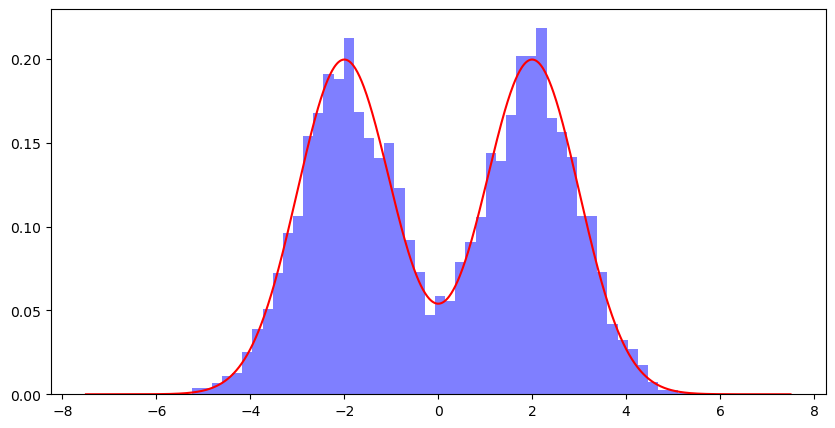

In [232]:
linspace = np.linspace(-7.5,7.5,1000)
plt.figure(figsize=(10,5))


N = 5000
X = sample_from_gaussian_mixture(N)

mixture_pdf = (stats.norm.pdf(linspace, -2, 1)+stats.norm.pdf(linspace, 2, 1))/2 # the density function of the mixture.

plt.plot(linspace, mixture_pdf,color = "red")
plt.hist(X,density=True,bins=round(N/100),color = "blue", alpha = 0.5)
plt.show()

## And now, lets plot our sampling distribution:

In [233]:
N=20

def sample_from_sampling_distribution(population_samples): # evaluates Z_N^*
    mu = 0 # mean of Z_N
    var = (1**2 + 1**2)/2 # variance of our population distribution
    std_zn = np.sqrt(var)/np.sqrt(N) # std-dev of Z_N
    
    Z_n = np.mean(population_samples)
    Z_n = (Z_n - mu)/std_zn
    return Z_n

In [234]:
num_sampling_distribution_samples = 5000
sampling_distribution_samples = []

for _ in range(num_sampling_distribution_samples):
    population_samples           = sample_from_gaussian_mixture(N)
    sampling_distribution_sample = sample_from_sampling_distribution(population_samples)
    
    sampling_distribution_samples.append(sampling_distribution_sample)


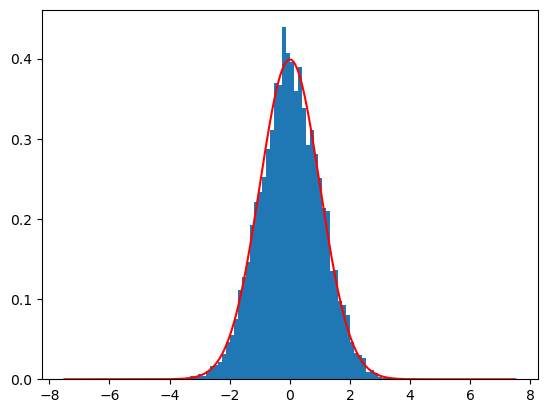

In [235]:
plt.hist(sampling_distribution_samples,density=True, bins=50)
plt.plot(linspace, stats.norm.pdf(linspace, 0, 1),color = "red")
plt.show()

# Median is more stable than the mean


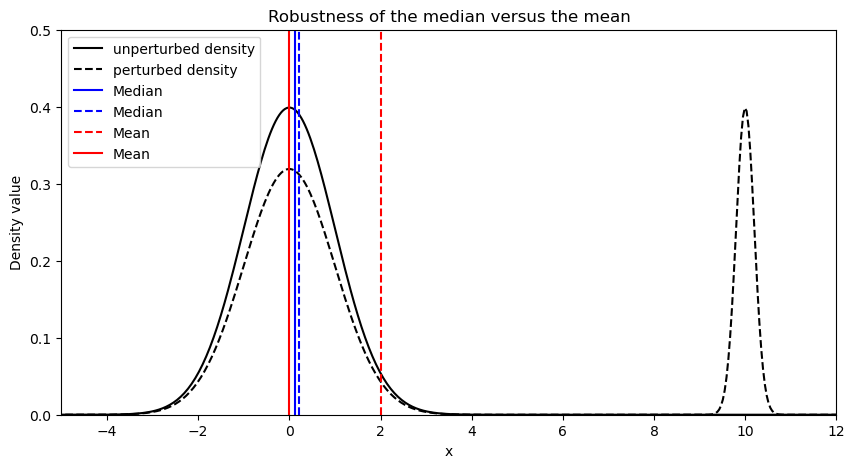

In [236]:
linspace = np.linspace(-20,20,1000)
plt.figure(figsize=(10,5))
eps = 0.1
unperturbed_mean, noise_mean = 0, 10
unperturbed_prop, noise_prop = 0.8, 0.2
unperturbed_median, noise_median = linspace[int(linspace.shape[0]/2)], linspace[int(linspace.shape[0]/2)] #ind=1000/2=500

unperturbed_pdf = stats.norm.pdf(linspace, unperturbed_mean, 1)
noise_pdf = stats.norm.pdf(linspace, noise_mean, 0.2)
perturbed_pdf = unperturbed_prop*unperturbed_pdf + noise_prop*noise_pdf

perturbed_mean = unperturbed_prop*unperturbed_mean + noise_prop*noise_mean
perturbed_median = (unperturbed_median + noise_median)/2

plt.plot(linspace, unperturbed_pdf, c='k', label='unperturbed density')
plt.plot(linspace, perturbed_pdf, c='k', linestyle='dashed', label='perturbed density')
plt.axvline(x=unperturbed_median+eps, c= 'blue', label = 'Median') # add eps for visualization
plt.axvline(x=perturbed_median+2*eps, c= 'blue', linestyle='dashed',label = 'Median') # add eps for visualization
plt.axvline(x=perturbed_mean, c= 'r', linestyle='dashed', label = 'Mean')
plt.axvline(x=unperturbed_mean, c= 'r', label = 'Mean')


# plt.plot(linspace, noise, c='m')
plt.xlim([-5,12])
plt.ylim([0,0.5])
plt.xlabel('x')
plt.ylabel('Density value')
plt.title('Robustness of the median versus the mean')
plt.legend()
plt.show()

### Sources 
https://github.com/ctgk/PRML <br>
https://www.programiz.com/python-programming/matrix <br>
https://matplotlib.org <br>
https://numpy.org/doc/
https://en.wikipedia.org/wiki/Mixture_distribution <br>